# Análisis 1: Evolución de Goles
## ¿El fútbol es más ofensivo o defensivo?

**Preguntas a responder:**
1. ¿El promedio de goles por partido ha disminuido con el tiempo?
2. ¿Los cambios de reglas (pase al portero 1992, 3 puntos 1994, VAR 2018) tuvieron impacto?
3. ¿La expansión del torneo diluyó la calidad y afectó los goles?
4. ¿Los goles se distribuyen uniformemente o se concentran en pocos partidos?

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append('..')
from src.visualization import set_style, plot_goals_by_decade, save_figure

set_style()

editions = pd.read_csv('../data/processed/editions_clean.csv')
matches = pd.read_csv('../data/processed/matches_clean.csv')
print('Data loaded successfully')

Data loaded successfully


## Análisis 1: Goles por década

Agrupar por década y calcular el promedio de goles por partido.

In [2]:
decade_goals = editions.groupby('decade')['goals_per_match'].agg(['mean', 'std', 'min', 'max']).round(2)
display(decade_goals)

,mean,std,min,max
decade,,,,
1930,4.23,0.40,3.89,4.67
1950,4.33,0.93,3.60,5.38
1960,2.78,0.00,2.78,2.78
1970,2.73,0.22,2.55,2.97
1980,2.68,0.19,2.54,2.81
1990,2.53,0.28,2.21,2.71
2000,2.41,0.16,2.30,2.52
2010,2.53,0.22,2.27,2.67
2020,2.69,NaN,2.69,2.69


Figure saved: c:\laragon\www\fifa_world_cup_data\reports\figures\goals_by_decade.png


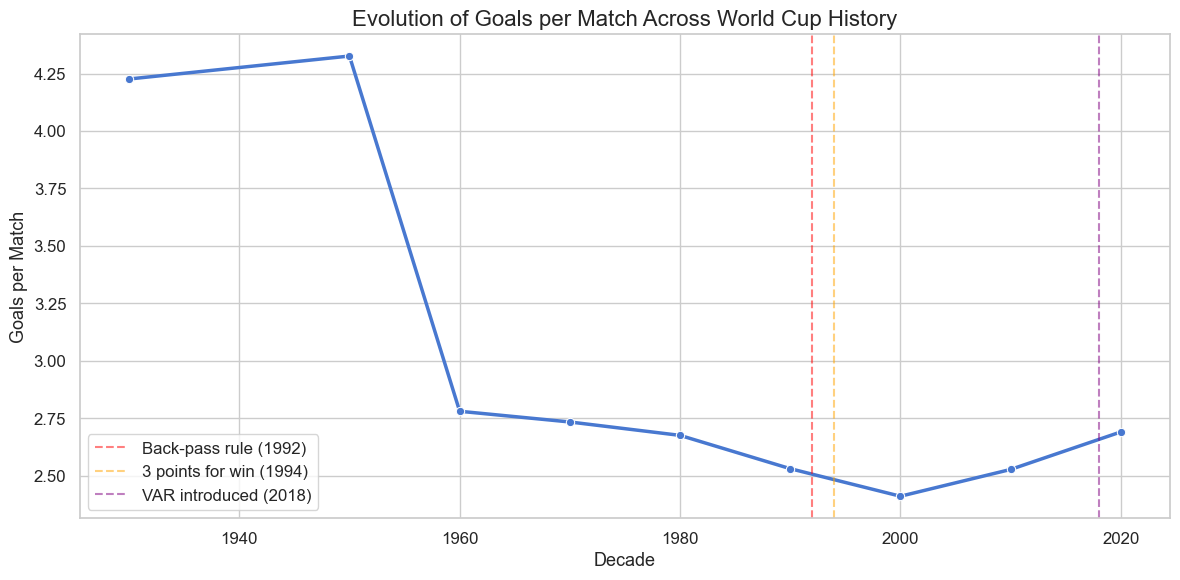

In [3]:
fig = plot_goals_by_decade(editions)
save_figure(fig, 'goals_by_decade')
plt.show()

## Análisis 2: Impacto de cambios de reglas

Comparar promedio de goles antes y después de cada cambio de regla.

In [4]:
before_backpass = editions[editions['year'] < 1992]['goals_per_match'].mean()
after_backpass = editions[editions['year'] >= 1992]['goals_per_match'].mean()
print(f'Before back-pass rule (1930-1990): {before_backpass:.2f} goals/match')
print(f'After back-pass rule (1994-2022): {after_backpass:.2f} goals/match')
print(f'Change: {((after_backpass - before_backpass) / before_backpass * 100):.1f}%')

Before back-pass rule (1930-1990): 3.36 goals/match
After back-pass rule (1994-2022): 2.56 goals/match
Change: -23.7%


In [5]:
before_3pts = editions[editions['year'] < 1994]['goals_per_match'].mean()
after_3pts = editions[editions['year'] >= 1994]['goals_per_match'].mean()
print(f'Before 3-point rule (1930-1990): {before_3pts:.2f}')
print(f'After 3-point rule (1994-2022): {after_3pts:.2f}')
print(f'Change: {((after_3pts - before_3pts) / before_3pts * 100):.1f}%')

Before 3-point rule (1930-1990): 3.36
After 3-point rule (1994-2022): 2.56
Change: -23.7%


## Análisis 3: Goles por ronda (group stage vs knockout)

In [6]:
goals_by_stage = matches.groupby(['year', 'is_knockout'])['total_goals'].mean().reset_index()
goals_by_stage['stage_type'] = goals_by_stage['is_knockout'].map({True: 'Knockout', False: 'Group Stage'})
display(goals_by_stage.head(10))

,year,is_knockout,total_goals,stage_type
0,1930,False,4.200000,Group Stage
1,1930,True,6.666667,Knockout
2,1934,True,4.285714,Knockout
3,1938,True,5.285714,Knockout
4,1950,False,2.500000,Group Stage
5,1950,True,5.333333,Knockout
6,1954,False,10.000000,Group Stage
7,1954,True,6.800000,Knockout
8,1958,False,6.500000,Group Stage
9,1958,True,6.200000,Knockout


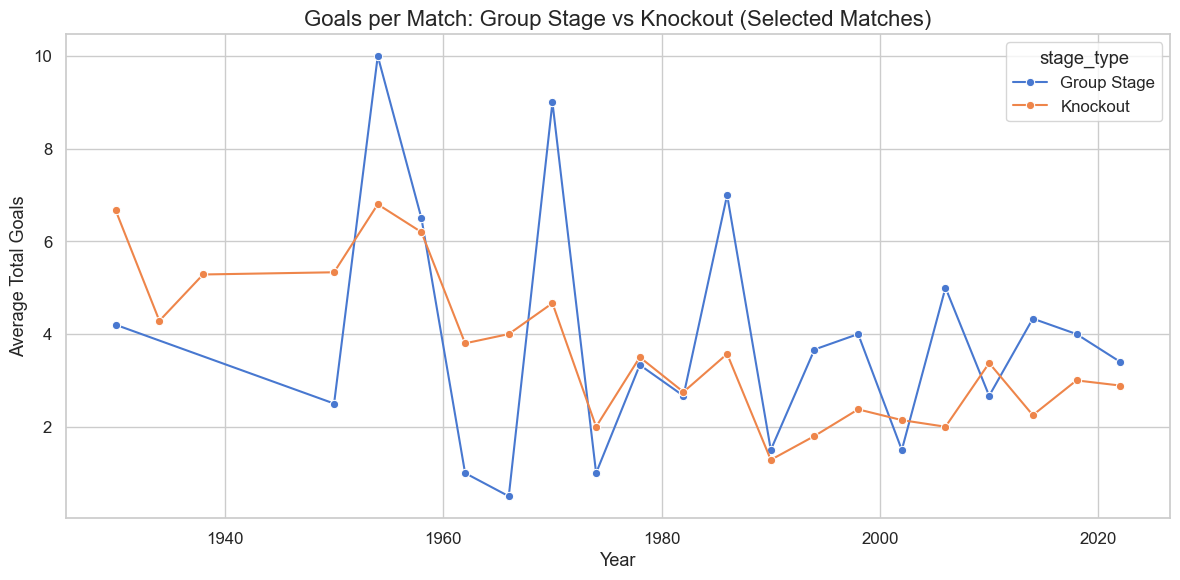

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=goals_by_stage, x='year', y='total_goals', hue='stage_type', marker='o', ax=ax)
ax.set_title('Goals per Match: Group Stage vs Knockout (Selected Matches)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Total Goals')
plt.tight_layout()
plt.show()

## Análisis 4: Distribución de goles por década

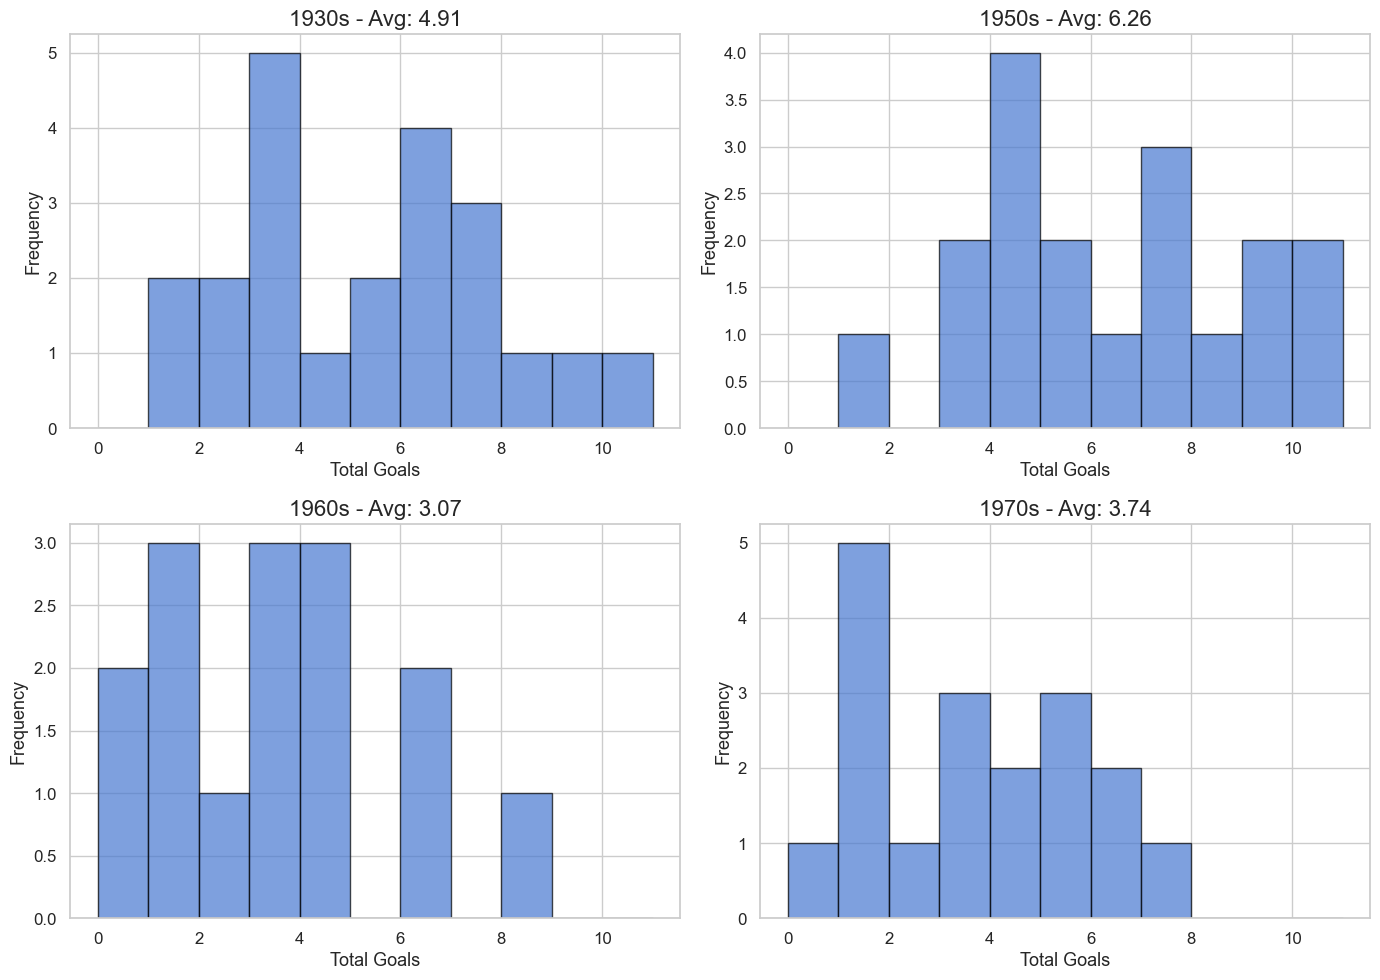

In [8]:
matches['decade'] = (matches['year'] // 10) * 10
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
decades = matches['decade'].unique()
for ax, decade in zip(axes.flatten(), sorted(decades)[:4]):
    data = matches[matches['decade'] == decade]['total_goals']
    ax.hist(data, bins=range(0, 12), alpha=0.7, edgecolor='black')
    ax.set_title(f'{decade}s - Avg: {data.mean():.2f}')
    ax.set_xlabel('Total Goals')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Conclusiones

**Escribe aquí tus hallazgos después de ejecutar las celdas anteriores.**

- ¿El promedio de goles ha disminuido?
- ¿Los cambios de reglas tuvieron impacto?
- ¿Hay diferencia entre group stage y knockout?